# 03 — Sensor Analysis & Degradation Trajectories (FD001)

**Phase 3 — FD001 Exploration**

Goals (per README "Sensor Analysis" section):
- Which sensors degrade before failure?
- Which sensors are nearly constant?
- Which sensors are noisy?
- Which sensors respond to operating conditions?
- Plot degradation trajectories for individual engines

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.data.ingestion import DataIngestion
from src.entity.config_entity import DataIngestionConfig
from src.config.config import SENSOR_COLUMNS

VARIANT = 'FD001'
data = DataIngestion(DataIngestionConfig(variant=VARIANT)).run(persist=False)
train_df = data['train']
train_df.shape

[2026-08-27 21:57:27] INFO     | src.data.ingestion | Loaded train_FD001.txt -> shape=(20631, 26), engines=100
[2026-08-27 21:57:27] INFO     | src.data.ingestion | Loaded test_FD001.txt -> shape=(13096, 26), engines=100
[2026-08-27 21:57:27] INFO     | src.data.ingestion | Loaded RUL_FD001.txt -> shape=(100, 2)


(20631, 26)

## Add a normalized "life fraction" column
For plotting degradation trends across engines with different lifetimes, it helps to express each cycle as a fraction of that engine's total life (0 = start, 1 = failure).

In [2]:
max_cycle = train_df.groupby('unit_number')['time_in_cycles'].transform('max')
train_df['life_fraction'] = train_df['time_in_cycles'] / max_cycle
train_df[['unit_number', 'time_in_cycles', 'life_fraction']].head()

,unit_number,time_in_cycles,life_fraction
0,1,1,0.005208
1,1,2,0.010417
2,1,3,0.015625
3,1,4,0.020833
4,1,5,0.026042


## Degradation trajectories — single engine
Plot every sensor's raw trajectory over the lifetime of one engine to visually spot which sensors trend up/down as failure approaches.

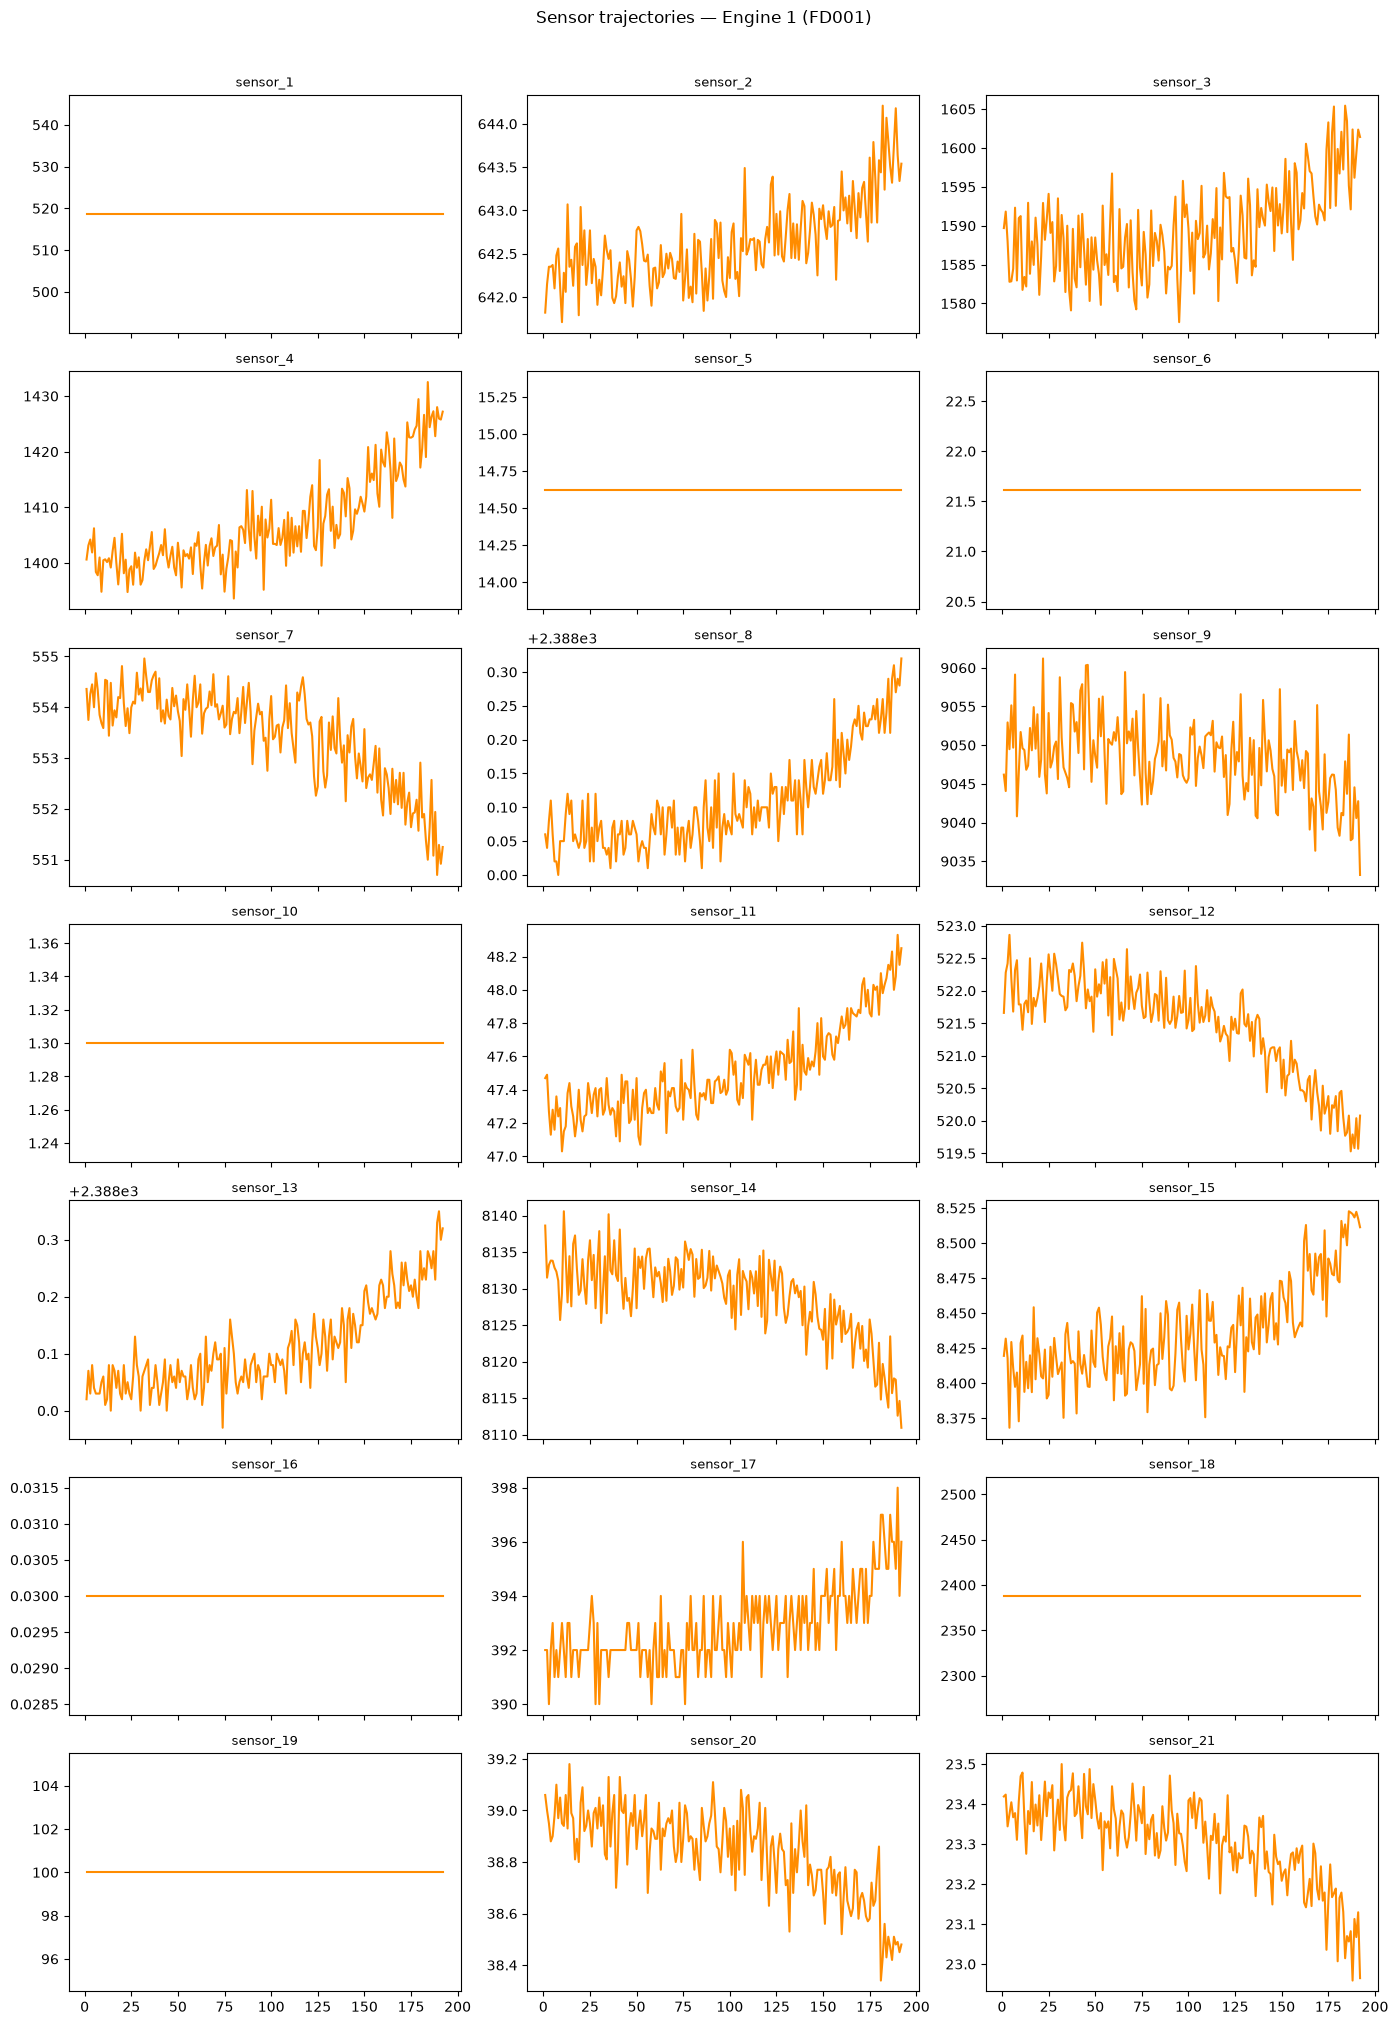

In [3]:
engine_id = 1
engine_df = train_df[train_df['unit_number'] == engine_id]

fig, axes = plt.subplots(7, 3, figsize=(14, 20), sharex=True)
for ax, col in zip(axes.flatten(), SENSOR_COLUMNS):
    ax.plot(engine_df['time_in_cycles'], engine_df[col], color='darkorange')
    ax.set_title(col, fontsize=9)
fig.suptitle(f'Sensor trajectories — Engine {engine_id} (FD001)', y=1.01)
plt.tight_layout()
plt.show()

## Degradation trajectories — multiple engines overlaid
Overlaying several engines (aligned by life fraction) makes it easier to see *consistent* degradation trends vs. noise.

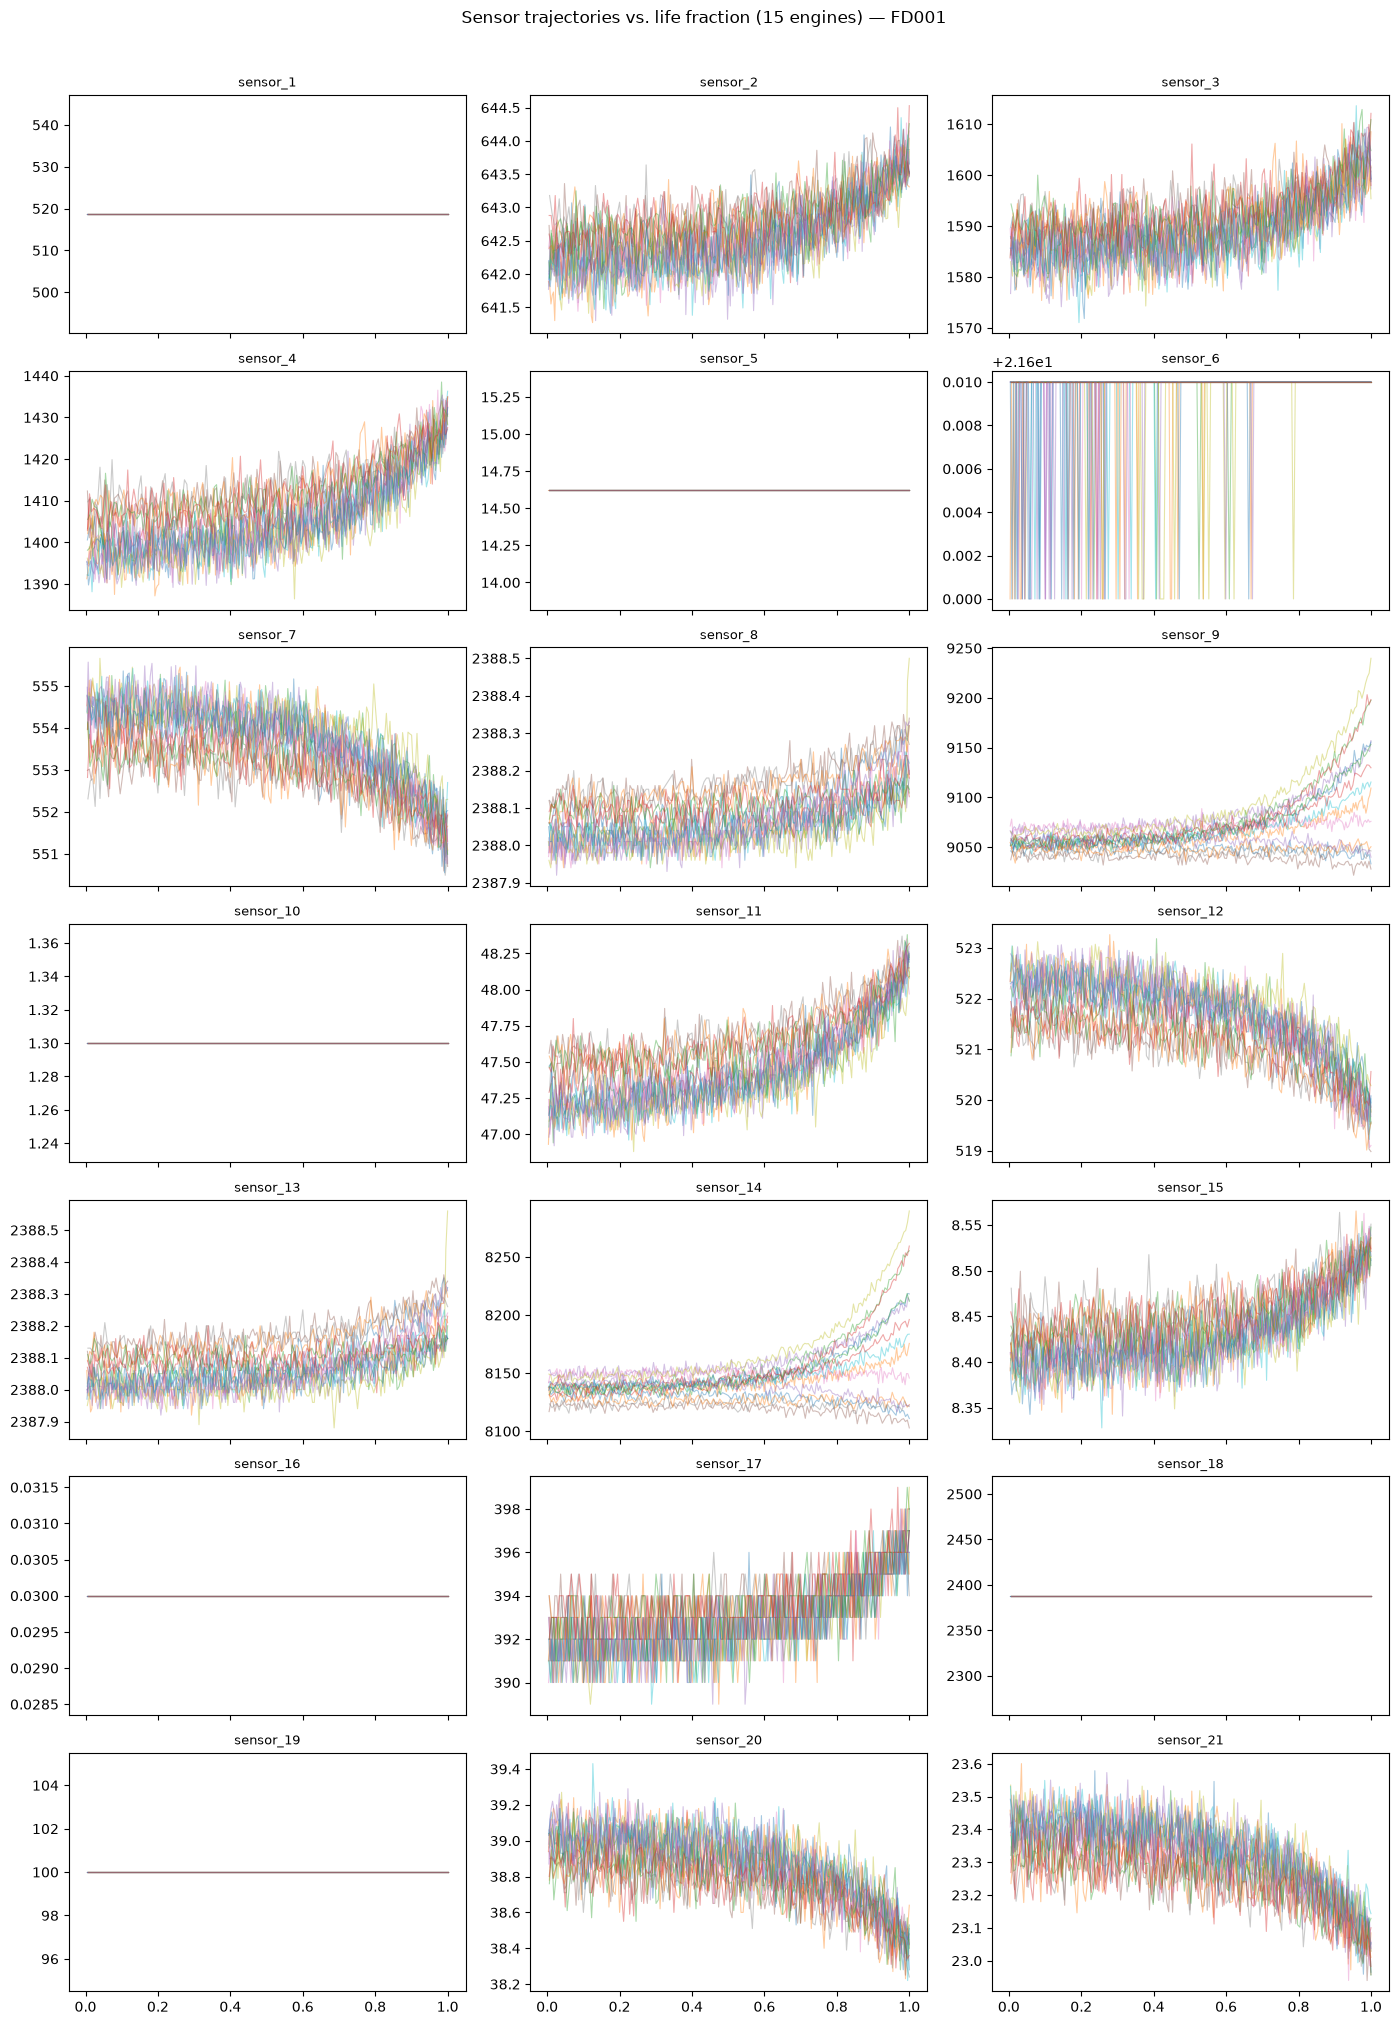

In [4]:
sample_engines = train_df['unit_number'].unique()[:15]

fig, axes = plt.subplots(7, 3, figsize=(14, 20), sharex=True)
for ax, col in zip(axes.flatten(), SENSOR_COLUMNS):
    for eng in sample_engines:
        sub = train_df[train_df['unit_number'] == eng]
        ax.plot(sub['life_fraction'], sub[col], alpha=0.4, linewidth=0.8)
    ax.set_title(col, fontsize=9)
fig.suptitle('Sensor trajectories vs. life fraction (15 engines) — FD001', y=1.01)
plt.tight_layout()
plt.show()

## Rank sensors by degradation signal strength
A simple proxy: correlation between `life_fraction` and each sensor's value. Sensors with |correlation| close to 1 move consistently with degradation; values near 0 suggest a weak or no direct trend (though non-linear trends may still be missed by this simple linear check).

In [5]:
degradation_corr = (
    train_df[SENSOR_COLUMNS + ['life_fraction']]
    .corr()['life_fraction']
    .drop('life_fraction')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
degradation_corr

sensor_11    0.727496
sensor_4     0.711539
sensor_12   -0.701873
sensor_7    -0.685233
sensor_15    0.672931
sensor_21   -0.666816
sensor_20   -0.663741
sensor_17    0.639694
sensor_2     0.632123
sensor_3     0.616009
sensor_13    0.573969
sensor_8     0.572982
sensor_9     0.448674
sensor_14    0.362541
sensor_6     0.121435
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: life_fraction, dtype: float64

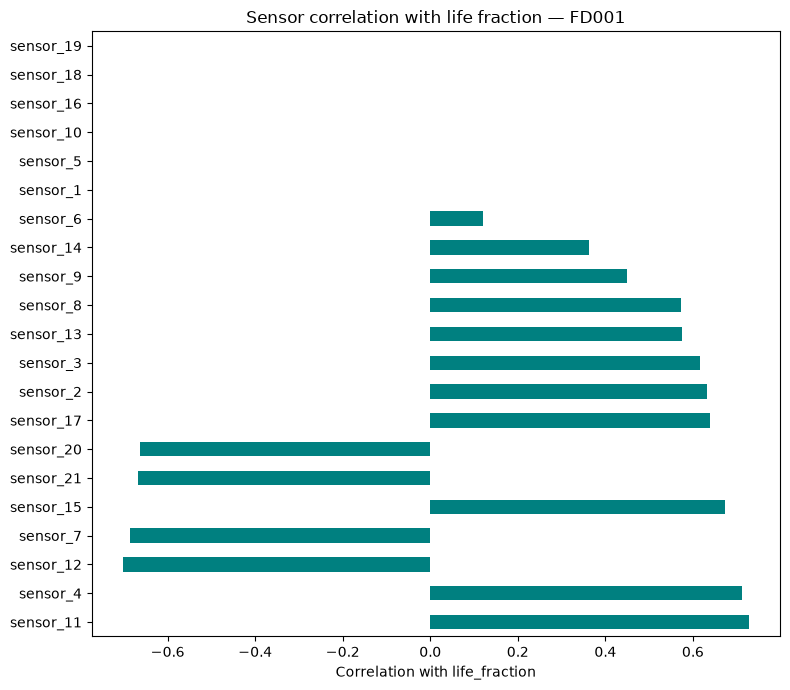

In [6]:
degradation_corr.plot(kind='barh', figsize=(8, 7), color='teal')
plt.title('Sensor correlation with life fraction — FD001')
plt.xlabel('Correlation with life_fraction')
plt.tight_layout()
plt.show()

## Sensor noise (within-engine volatility)
Sensors with high rolling standard deviation relative to their range are noisier and may need smoothing in Phase 5 (Feature Engineering).

In [7]:
noise_scores = {}
for col in SENSOR_COLUMNS:
    per_engine_std = train_df.groupby('unit_number')[col].std()
    noise_scores[col] = per_engine_std.mean()

noise_series = pd.Series(noise_scores).sort_values(ascending=False)
noise_series

sensor_9     14.189053
sensor_14    11.804007
sensor_4      8.118497
sensor_3      5.788760
sensor_17     1.450997
sensor_7      0.786467
sensor_12     0.648178
sensor_2      0.462850
sensor_11     0.237445
sensor_20     0.166420
sensor_21     0.099550
sensor_13     0.057271
sensor_8      0.056596
sensor_15     0.034465
sensor_6      0.000959
sensor_10     0.000000
sensor_16     0.000000
sensor_18     0.000000
sensor_19     0.000000
sensor_5      0.000000
sensor_1      0.000000
dtype: float64

## Summary — sensors to watch
Combine the degradation-correlation and noise findings into a single reference table. This will directly inform feature selection in **Phase 5 — Feature Engineering**.

In [8]:
summary = pd.DataFrame({
    'degradation_corr': degradation_corr,
    'abs_degradation_corr': degradation_corr.abs(),
    'noise_std': noise_series,
}).sort_values('abs_degradation_corr', ascending=False)

summary

,degradation_corr,abs_degradation_corr,noise_std
sensor_11,0.727496,0.727496,0.237445
sensor_4,0.711539,0.711539,8.118497
sensor_12,-0.701873,0.701873,0.648178
sensor_7,-0.685233,0.685233,0.786467
sensor_15,0.672931,0.672931,0.034465
sensor_21,-0.666816,0.666816,0.099550
sensor_20,-0.663741,0.663741,0.166420
sensor_17,0.639694,0.639694,1.450997
sensor_2,0.632123,0.632123,0.462850
sensor_3,0.616009,0.616009,5.788760


In [9]:
summary.to_csv('../reports/metrics/sensor_analysis_summary_FD001.csv')
print('Saved to reports/metrics/sensor_analysis_summary_FD001.csv')

Saved to reports/metrics/sensor_analysis_summary_FD001.csv


## Next
Phase 3 (FD001 Exploration) is complete. Phase 4 (**04_rul_generation.ipynb**) will compute the RUL regression target from these run-to-failure trajectories.